### Imports e Configuração de Ambiente

In [16]:
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_curve, auc

# Garante a execução na raiz do projeto
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

con = duckdb.connect()
print("✅ Ambiente configurado!")

✅ Ambiente configurado!


### Leitura e Consolidação das Bases com DuckDB (Passo 1)

In [17]:
# 1. Agregações relacionais (Visão Contrato)
con.execute("""
    CREATE OR REPLACE VIEW vw_bureau_agg AS
    SELECT 
        SK_ID_CURR AS id_cliente,
        COUNT(SK_ID_BUREAU) AS bureau_qtd_creditos,
        COUNT(CASE WHEN CREDIT_ACTIVE = 'Active' THEN 1 END) AS bureau_qtd_ativos,
        ROUND(SUM(COALESCE(AMT_CREDIT_SUM, 0)), 2) AS bureau_total_credito,
        ROUND(SUM(COALESCE(AMT_CREDIT_SUM_DEBT, 0)), 2) AS bureau_total_divida
    FROM 'data/bureau.parquet'
    GROUP BY SK_ID_CURR;
""")

# 2. Consolidação da base de Treino
df_abt_treino_p1 = con.execute("""
    SELECT 
        app.SK_ID_CURR AS id_cliente,
        app.TARGET AS target,
        app.NAME_CONTRACT_TYPE,
        app.CODE_GENDER,
        app.FLAG_OWN_CAR,
        app.FLAG_OWN_REALTY,
        app.AMT_INCOME_TOTAL,
        app.AMT_CREDIT,
        app.AMT_ANNUITY,
        CASE WHEN app.DAYS_EMPLOYED = 365243 THEN NULL ELSE app.DAYS_EMPLOYED END AS DAYS_EMPLOYED,
        app.DAYS_BIRTH,
        COALESCE(b.bureau_qtd_creditos, 0) AS bureau_qtd_creditos,
        COALESCE(b.bureau_qtd_ativos, 0) AS bureau_qtd_ativos,
        COALESCE(b.bureau_total_credito, 0) AS bureau_total_credito,
        COALESCE(b.bureau_total_divida, 0) AS bureau_total_divida
    FROM 'data/application_train.parquet' app
    LEFT JOIN vw_bureau_agg b ON app.SK_ID_CURR = b.id_cliente
""").df()

# 3. Consolidação da base de Teste (se existir)
df_abt_teste_p1 = con.execute("""
    SELECT 
        app.SK_ID_CURR AS id_cliente,
        app.NAME_CONTRACT_TYPE,
        app.CODE_GENDER,
        app.FLAG_OWN_CAR,
        app.FLAG_OWN_REALTY,
        app.AMT_INCOME_TOTAL,
        app.AMT_CREDIT,
        app.AMT_ANNUITY,
        CASE WHEN app.DAYS_EMPLOYED = 365243 THEN NULL ELSE app.DAYS_EMPLOYED END AS DAYS_EMPLOYED,
        app.DAYS_BIRTH,
        COALESCE(b.bureau_qtd_creditos, 0) AS bureau_qtd_creditos,
        COALESCE(b.bureau_qtd_ativos, 0) AS bureau_qtd_ativos,
        COALESCE(b.bureau_total_credito, 0) AS bureau_total_credito,
        COALESCE(b.bureau_total_divida, 0) AS bureau_total_divida
    FROM 'data/application_test.parquet' app
    LEFT JOIN vw_bureau_agg b ON app.SK_ID_CURR = b.id_cliente
""").df() if os.path.exists("data/application_test.parquet") else df_abt_treino_p1.head(100).drop(columns=["target"])

print(f"✅ Treino carregado: {df_abt_treino_p1.shape}")
print(f"✅ Teste carregado: {df_abt_teste_p1.shape}")

✅ Treino carregado: (307511, 15)
✅ Teste carregado: (48744, 14)


### OptBinning e Transformação WoE (Passo 2)

In [18]:
print("1. Coletando bases e executando OptBinning em Pandas...")

colunas_ignorar = [c.lower() for c in ["id_cliente", "target", "sk_id_curr"]]
colunas_analise = [c for c in df_abt_treino_p1.columns if c.lower() not in colunas_ignorar]

pdf_treino = df_abt_treino_p1.copy()
pdf_teste = df_abt_teste_p1.copy()

mapa_iv = {}
pdf_treino_woe = pd.DataFrame()
pdf_teste_woe = pd.DataFrame()

for col in colunas_analise:
    dtype = "categorical" if pdf_treino[col].dtype == "object" else "numerical"
    optb = OptimalBinning(name=col, dtype=dtype, solver="cp")

    try:
        optb.fit(pdf_treino[col], pdf_treino["target"])
        iv = optb.binning_table.build()["IV"].to_list()[-1]
        mapa_iv[col] = iv

        pdf_treino_woe[f"{col}_woe"] = optb.transform(pdf_treino[col], metric="woe")
        pdf_teste_woe[f"{col}_woe"] = optb.transform(pdf_teste[col], metric="woe")
    except Exception:
        mapa_iv[col] = 0.0

# Filtro de IV (0.02 <= IV < 0.50)
features_relevantes = [f"{col}_woe" for col, iv in mapa_iv.items() if 0.02 <= iv < 0.50]

# Preservar chaves e resposta
pdf_treino_woe["id_cliente"] = pdf_treino["id_cliente"]
pdf_treino_woe["target"] = pdf_treino["target"]
pdf_teste_woe["id_cliente"] = pdf_teste["id_cliente"]

print(f"✅ Passo 2 concluído! Total de features selecionadas por IV: {len(features_relevantes)}")

1. Coletando bases e executando OptBinning em Pandas...
✅ Passo 2 concluído! Total de features selecionadas por IV: 6


### Divisão Estratificada dos Dados (Passo 3)

In [19]:
X = pdf_treino_woe[features_relevantes]
y = pdf_treino_woe["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ Passo 3 concluído! Divisão de dados:")
print(f"   • Treino    : {len(X_train):,} linhas (Taxa Bad: {y_train.mean()*100:.2f}%)")
print(f"   • Validação : {len(X_val):,} linhas (Taxa Bad: {y_val.mean()*100:.2f}%)")

✅ Passo 3 concluído! Divisão de dados:
   • Treino    : 246,008 linhas (Taxa Bad: 8.07%)
   • Validação : 61,503 linhas (Taxa Bad: 8.07%)


### Treinamento do Modelo e Métricas (Passo 4)

In [20]:
gbc = GradientBoostingClassifier(
    n_estimators=40,
    max_depth=4,
    random_state=42
)

print("2. Treinando o modelo GradientBoostingClassifier...")
gbc.fit(X_train, y_train)

# Previsão na Validação
y_val_prob = gbc.predict_proba(X_val)[:, 1]

# Métricas ROC e KS
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
auc_val = auc(fpr, tpr)

df_ks_pd = pd.DataFrame({'target': y_val, 'prob': y_val_prob}).sort_values(by='prob', ascending=False).reset_index(drop=True)
df_ks_pd['cum_bads'] = (df_ks_pd['target'] == 1).cumsum() / (df_ks_pd['target'] == 1).sum()
df_ks_pd['cum_goods'] = (df_ks_pd['target'] == 0).cumsum() / (df_ks_pd['target'] == 0).sum()
ks_max = np.abs(df_ks_pd['cum_bads'] - df_ks_pd['cum_goods']).max()

print("\n" + "="*45)
print("    DESEMPENHO DO MODELO NA VALIDAÇÃO           ")
print("="*45)
print(f" ROC-AUC : {auc_val:.4f}")
print(f" KS      : {ks_max * 100:.2f}%")
print(f" Gini    : {2 * auc_val - 1:.4f}")
print("="*45)

2. Treinando o modelo GradientBoostingClassifier...

    DESEMPENHO DO MODELO NA VALIDAÇÃO           
 ROC-AUC : 0.6524
 KS      : 22.29%
 Gini    : 0.3049


### Predição na Base de Teste (Passo 5)

In [21]:
X_teste = pdf_teste_woe[features_relevantes]

pdf_predicoes_teste = pd.DataFrame({
    'SK_ID_CURR': pdf_teste_woe['id_cliente'],
    'probabilidade_inadimplencia': np.round(gbc.predict_proba(X_teste)[:, 1], 4)
})

print(f"✅ Passo 5 concluído! Total de predições no Teste: {len(pdf_predicoes_teste):,} linhas")
display(pdf_predicoes_teste.head())

✅ Passo 5 concluído! Total de predições no Teste: 48,744 linhas


,SK_ID_CURR,probabilidade_inadimplencia
0,186127,0.1545
1,172771,0.0429
2,348177,0.0465
3,261871,0.0411
4,153802,0.0658


### Visualização - Árvore de Decisão

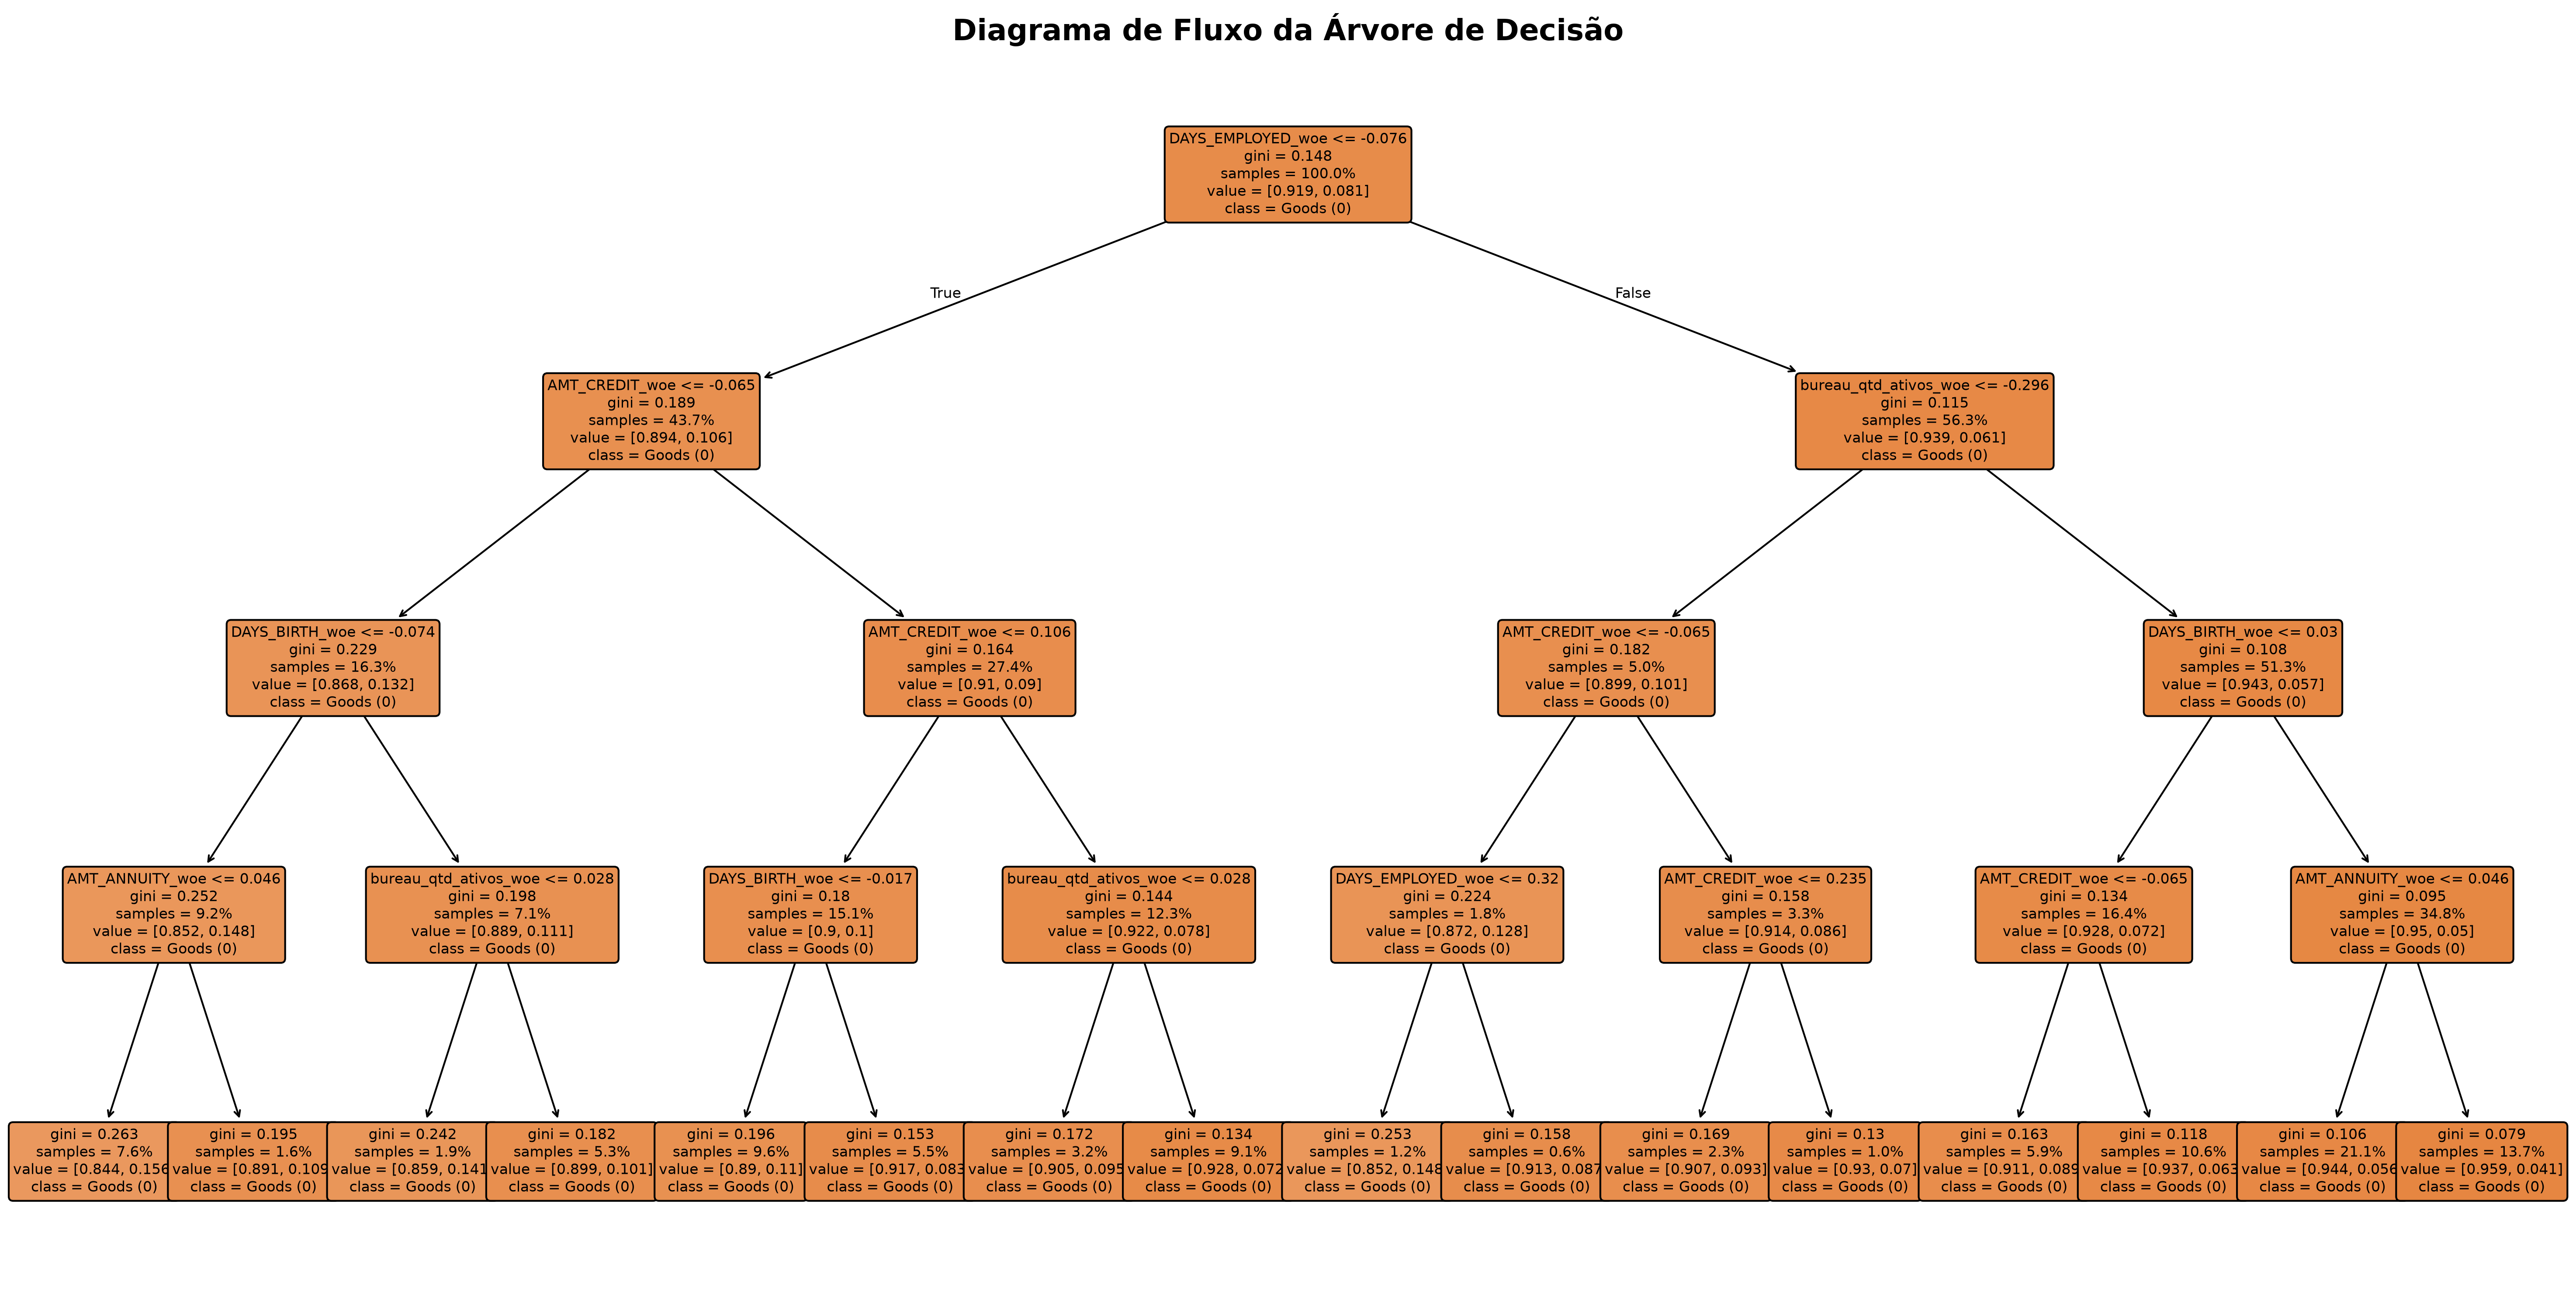

In [22]:
dt_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_tree.fit(X_train, y_train)

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    dt_tree,
    feature_names=features_relevantes,
    class_names=['Goods (0)', 'Bads (1)'],
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True
)
plt.title("Diagrama de Fluxo da Árvore de Decisão", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualização - Curva ROC e Curva KS

### Curva ROC

In [23]:
import plotly.graph_objects as go

fig_roc = go.Figure()

# Linha do Modelo
fig_roc.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode="lines",
        name=f"GBC (AUC = {auc_val:.4f})",
        line=dict(color="#1f77b4", width=3),
    )
)

# Linha de Referência Aleatória
fig_roc.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Aleatório (AUC = 0.50)",
        line=dict(color="gray", width=2, dash="dash"),
    )
)

fig_roc.update_layout(
    title="<b>Curva ROC - Validação</b>",
    xaxis_title="Taxa de Falsos Positivos (1 - Especificidade)",
    yaxis_title="Taxa de Verdadeiros Positivos (Sensibilidade)",
    template="plotly_white",
    width=750,
    height=500,
    hovermode="x unified",
)

fig_roc.show()

### Curva KS

In [24]:

pop_pct = np.linspace(0, 100, len(df_ks_pd))
max_ks_idx = np.abs(df_ks_pd["cum_bads"] - df_ks_pd["cum_goods"]).idxmax()
pct_pop_max = (max_ks_idx + 1) / len(df_ks_pd) * 100

fig_ks = go.Figure()

# Inadimplentes (Bads)
fig_ks.add_trace(
    go.Scatter(
        x=pop_pct,
        y=df_ks_pd["cum_bads"] * 100,
        mode="lines",
        name="Inadimplentes (Bads)",
        line=dict(color="#d62728", width=3),
    )
)

# Adimplentes (Goods)
fig_ks.add_trace(
    go.Scatter(
        x=pop_pct,
        y=df_ks_pd["cum_goods"] * 100,
        mode="lines",
        name="Adimplentes (Goods)",
        line=dict(color="#1f77b4", width=3),
    )
)

# Marcação do Ponto de KS Máximo
fig_ks.add_vline(
    x=pct_pop_max,
    line_width=2,
    line_dash="dash",
    line_color="black",
    annotation_text=f"<b>KS Máximo = {ks_max*100:.2f}%</b>",
    annotation_position="top left",
)

fig_ks.update_layout(
    title="<b>Curva KS (Kolmogorov-Smirnov)</b>",
    xaxis_title="Percentual Acumulado da População (%)",
    yaxis_title="Percentual Acumulado de Clientes (%)",
    template="plotly_white",
    width=800,
    height=500,
    hovermode="x unified",
)

fig_ks.show()